# 03 — Feature Engineering

In this notebook we construct **predictive features** from the processed data created in the previous step.

At this stage the data consists of two separate datasets:

- **LOB data** containing order book snapshots with bid and ask prices and volumes at multiple depth levels.
- **Trade data** containing executed trades over time.

The goal of this notebook is to transform these raw structures into **useful market microstructure variables** that describe the state of the market. These features will capture aspects such as liquidity, order flow, price pressure, momentum, and short-term volatility.

The resulting features will later be combined into a **single modelling dataset** 

In [1]:
import pandas as pd
import numpy as np
from binance.client import Client
import time
import black
from pympler import asizeof
import math
import matplotlib.pyplot as plt
import glob

pd.set_option("display.max_columns", None)

e:\anaconda3\envs\lob-alpha\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(


# load in interim dataset

In [2]:
files_trades = glob.glob(
    "E:\\Quant_Projects\\microstructure-alpha-engine\\microstructure-alpha-engine\\data\\interim\\trades*"
)
files_lob = glob.glob(
    "E:\\Quant_Projects\\microstructure-alpha-engine\\microstructure-alpha-engine\\data\\interim\\lob_snapshot*"
)
lob_df = pd.concat([pd.read_parquet(f) for f in files_lob])
trade_df = pd.concat([pd.read_parquet(f) for f in files_trades])

trade_df

,id,price,qty,quoteQty,time,isBuyerMaker,isBestMatch,timestamp
1000,6086761823,69913.84,0.00008,5.593107,1773122650687,False,True,1773122649927
1001,6086761822,69913.80,0.00008,5.593104,1773122650687,False,True,1773122649927
1002,6086761826,69913.85,0.00008,5.593108,1773122650687,False,True,1773122649927
1003,6086761827,69913.85,0.00008,5.593108,1773122650687,False,True,1773122649927
1004,6086761824,69913.85,0.00008,5.593108,1773122650687,False,True,1773122649927
...,...,...,...,...,...,...,...,...
254804,6087019438,70344.75,0.09021,6345.799898,1773128553949,False,True,1773128552519
254805,6087019439,70344.74,0.00571,401.668465,1773128553955,True,True,1773128552519
254806,6087019440,70344.74,0.00106,74.565424,1773128554030,True,True,1773128553986
254807,6087019441,70344.75,0.00025,17.586188,1773128554358,False,True,1773128553986


# Creating the variables for Limit order books

In [3]:
EPS = 1e-9

In [4]:
def create_lob_price_features(df):
    df["mid_price"] = (df["lob_bids_price_1"] + df["lob_asks_price_1"]) / 2
    df["spread"] = df["lob_asks_price_1"] - df["lob_bids_price_1"]
    df["rel_spread"] = df["spread"] / (df["mid_price"] + EPS)
    return df


def lob_volume_features(df):
    df["liquidity"] = df["lob_bids_volume_1"] + df["lob_asks_volume_1"]
    df["total_bid_volume_10"] = df[[f"lob_bids_volume_{i}" for i in range(1, 11)]].sum(
        axis=1
    )
    df["total_ask_volume_10"] = df[[f"lob_asks_volume_{i}" for i in range(1, 11)]].sum(
        axis=1
    )
    df["total_book_volume"] = df["total_ask_volume_10"] + df["total_bid_volume_10"]
    df["max_bid_ask_vol_ratio"] = df["lob_bids_volume_1"] / (
        df["lob_asks_volume_1"] + EPS
    )
    return df


def lob_pressure_features(df):

    df["imbalance_1"] = (df["lob_bids_volume_1"] - df["lob_asks_volume_1"]) / (
        df["lob_bids_volume_1"] + df["lob_asks_volume_1"] + EPS
    )
    for i in range(2, 11):
        bid_col = f"lob_bids_volume_{i}"
        ask_col = f"lob_asks_volume_{i}"

        if bid_col in df.columns and ask_col in df.columns:
            bid = df[bid_col]
            ask = df[ask_col]

            df[f"log_depth_ratio_{i}"] = np.log((bid + EPS) / (ask + EPS))        
    
    
    
    
    bid_vol5 = df[[f"lob_bids_volume_{i}" for i in range(1, 6)]].sum(axis=1)
    ask_vol5 = df[[f"lob_asks_volume_{i}" for i in range(1, 6)]].sum(axis=1)

    df["imbalance_5"] = (bid_vol5 - ask_vol5) / (bid_vol5 + ask_vol5 + EPS)

    bid10 = df[[f"lob_bids_volume_{i}" for i in range(1, 11)]].sum(axis=1)
    ask10 = df[[f"lob_asks_volume_{i}" for i in range(1, 11)]].sum(axis=1)

    df["imbalance_10"] = (bid10 - ask10) / (bid10 + ask10 + EPS)

    for i in range(1, 11):
        bid_col = f"lob_bids_volume_{i}"
        ask_col = f"lob_asks_volume_{i}"

        if bid_col in df.columns and ask_col in df.columns:
            bid = df[bid_col]#.fillna(0)
            ask = df[ask_col]#.fillna(0)

            df[f"imbalance_depth_{i}"] = (bid - ask) / (bid + ask + EPS)

    df["microprice"] = (
        df["lob_bids_volume_1"] * df["lob_asks_price_1"]
        + df["lob_asks_volume_1"] * df["lob_bids_price_1"]
    ) / (df["liquidity"] + EPS)

    df["microprice_change"] = df["microprice"].diff()
    df["mid_minus_micro"] = df["mid_price"] - df["microprice"]

    numerator10 = sum(
        df[f"lob_bids_volume_{i}"] * df[f"lob_asks_price_{i}"]
        + df[f"lob_asks_volume_{i}"] * df[f"lob_bids_price_{i}"]
        for i in range(1, 11)
    )

    denominator10 = sum(
        df[f"lob_bids_volume_{i}"] + df[f"lob_asks_volume_{i}"] for i in range(1, 11)
    )
    df["microprice_weighted_10"] = numerator10 / (denominator10 + EPS)
    return df


def lob_returns_and_momentum_features(df):
    df["return_1"] = df["mid_price"].pct_change(1)
    df["return_5"] = df["mid_price"].pct_change(5)

    df["log_return_1"] = np.log(df["mid_price"]).diff(1)
    df["log_return_2"] = np.log(df["mid_price"]).diff(2)
    df["log_return_3"] = np.log(df["mid_price"]).diff(3)
    df["log_return_5"] = np.log(df["mid_price"]).diff(5)
    df["log_return_20"] = np.log(df["mid_price"]).diff(20)
    # momentum based return

    df["momentum_5_log_return_1"] = df["log_return_1"].rolling(5).mean()
    df["momentum_20_log_return_1"] = df["log_return_1"].rolling(20).mean()

    return df


def lob_volatility_features(df):
    df["vol_5"] = df["log_return_1"].rolling(5).std()
    df["vol_20"] = df["log_return_1"].rolling(20).std()

    df["realized_vol_5"] = np.sqrt((df["log_return_1"] ** 2).rolling(5).sum())
    df["realized_vol_20"] = np.sqrt((df["log_return_1"] ** 2).rolling(20).sum())
    return df


def lob_target_feature(df, horizons=(1, 5, 20)):
    for h in horizons:
        df[f"mid_price_change_{h}"] = df["mid_price"].shift(-h) - df["mid_price"]
        df[f"mid_price_change_{h}_sign"] = np.sign(df[f"mid_price_change_{h}"])
    return df

## Pipeline

In [5]:
def build_lob_feature_pipeline(df):

    df = create_lob_price_features(df)

    df = lob_volume_features(df)

    df = lob_pressure_features(df)

    df = lob_returns_and_momentum_features(df)

    df = lob_volatility_features(df)

    df = lob_target_feature(df)

    return df

# Create trade features

In [6]:
def trade_base_features(trade_df):

    df = trade_df.copy()

    df["buy_trade"] = (df["isBuyerMaker"] == False).astype(int)
    df["sell_trade"] = (df["isBuyerMaker"] == True).astype(int)

    df["buy_qty"] = df["qty"].where(df["isBuyerMaker"] == False, 0)
    df["sell_qty"] = df["qty"].where(df["isBuyerMaker"] == True, 0)

    df["price_qty"] = df["price"] * df["qty"]

    agg = df.groupby("timestamp").agg(
        trade_count=("qty", "count"),
        buy_count=("buy_trade", "sum"),
        sell_count=("sell_trade", "sum"),
        total_trade_volume=("qty", "sum"),
        buy_volume=("buy_qty", "sum"),
        sell_volume=("sell_qty", "sum"),
        avg_trade_size=("qty", "mean"),
        max_trade_size=("qty", "max"),
        min_trade_size=("qty", "min"),
        std_trade_size=("qty", "std"),
        vwap_num=("price_qty", "sum"),
    )

    agg["vwap"] = agg["vwap_num"] / (agg["total_trade_volume"] + EPS)
    agg["max_over_average"] = agg["max_trade_size"] / agg["avg_trade_size"]
    agg = agg.drop(columns="vwap_num")

    return agg.reset_index()


def trade_pressure_features(df):
    df["trade_volume_imbalance"] = (df["buy_volume"] - df["sell_volume"]) / (
        df["buy_volume"] + df["sell_volume"] + EPS
    )

    return df


def trade_change_features(df):

    df["trade_volume_change"] = df["total_trade_volume"].diff()

    df["trade_count_change"] = df["trade_count"].diff()

    return df


def trade_lag_features(df):

    df["lag_trade_volume_imbalance_1"] = df["trade_volume_imbalance"].shift(1)
    df["lag_trade_volume_imbalance_2"] = df["trade_volume_imbalance"].shift(2)
    df["lag_trade_volume_imbalance_3"] = df["trade_volume_imbalance"].shift(3)
    df["lag_trade_volume_imbalance_5"] = df["trade_volume_imbalance"].shift(5)

    return df

## Pileline

In [7]:
def build_trade_feature_pipeline(df):
    df = trade_base_features(df)

    df = trade_pressure_features(df)

    df = trade_change_features(df)

    df = trade_lag_features(df)

    return df

In [8]:
def merge_lob_and_trade(trade_features_df, lob_features_df):
    final_df = lob_features_df.merge(trade_features_df, on="timestamp", how="left")
    return final_df

# Building features and Final dataset and saving

In [9]:
lob_with_features = build_lob_feature_pipeline(lob_df)
trade_with_features = build_trade_feature_pipeline(trade_df)

final_dataset = merge_lob_and_trade(trade_with_features, lob_with_features)

final_dataset.dropna(inplace=True)
final_dataset = final_dataset.reset_index(drop=True)

PATH = "E:\\Quant_Projects\\microstructure-alpha-engine\\microstructure-alpha-engine\\data\\processed\\final_dataset.parquet"

final_dataset.to_parquet(
    PATH,
    compression="snappy",
)
final_dataset.head()

,timestamp,lob_bids_price_1,lob_bids_price_2,lob_bids_price_3,lob_bids_price_4,lob_bids_price_5,lob_bids_price_6,lob_bids_price_7,lob_bids_price_8,lob_bids_price_9,lob_bids_price_10,lob_bids_volume_1,lob_bids_volume_2,lob_bids_volume_3,lob_bids_volume_4,lob_bids_volume_5,lob_bids_volume_6,lob_bids_volume_7,lob_bids_volume_8,lob_bids_volume_9,lob_bids_volume_10,lob_asks_price_1,lob_asks_price_2,lob_asks_price_3,lob_asks_price_4,lob_asks_price_5,lob_asks_price_6,lob_asks_price_7,lob_asks_price_8,lob_asks_price_9,lob_asks_price_10,lob_asks_volume_1,lob_asks_volume_2,lob_asks_volume_3,lob_asks_volume_4,lob_asks_volume_5,lob_asks_volume_6,lob_asks_volume_7,lob_asks_volume_8,lob_asks_volume_9,lob_asks_volume_10,mid_price,spread,rel_spread,liquidity,total_bid_volume_10,total_ask_volume_10,total_book_volume,max_bid_ask_vol_ratio,imbalance_1,log_depth_ratio_2,log_depth_ratio_3,log_depth_ratio_4,log_depth_ratio_5,log_depth_ratio_6,log_depth_ratio_7,log_depth_ratio_8,log_depth_ratio_9,log_depth_ratio_10,imbalance_5,imbalance_10,imbalance_depth_1,imbalance_depth_2,imbalance_depth_3,imbalance_depth_4,imbalance_depth_5,imbalance_depth_6,imbalance_depth_7,imbalance_depth_8,imbalance_depth_9,imbalance_depth_10,microprice,microprice_change,mid_minus_micro,microprice_weighted_10,return_1,return_5,log_return_1,log_return_2,log_return_3,log_return_5,log_return_20,momentum_5_log_return_1,momentum_20_log_return_1,vol_5,vol_20,realized_vol_5,realized_vol_20,mid_price_change_1,mid_price_change_1_sign,mid_price_change_5,mid_price_change_5_sign,mid_price_change_20,mid_price_change_20_sign,trade_count,buy_count,sell_count,total_trade_volume,buy_volume,sell_volume,avg_trade_size,max_trade_size,min_trade_size,std_trade_size,vwap,max_over_average,trade_volume_imbalance,trade_volume_change,trade_count_change,lag_trade_volume_imbalance_1,lag_trade_volume_imbalance_2,lag_trade_volume_imbalance_3,lag_trade_volume_imbalance_5
0,1773122679257,69902.03,69902.02,69902.00,69901.44,69900.80,69900.00,69899.71,69899.70,69899.65,69899.56,1.07649,0.00056,0.00040,0.00008,0.00008,0.00090,0.00016,0.00794,0.00030,0.00008,69902.04,69902.05,69902.09,69902.10,69902.11,69902.24,69902.25,69903.63,69903.64,69903.65,1.59227,0.05064,0.00008,0.05008,0.01153,0.00008,0.01174,0.00016,0.22780,0.00008,69902.035,0.01,1.430574e-07,2.66876,1.08699,1.94446,3.03145,0.676073,-0.193266,-4.504559,1.609428,-6.439338,-4.970669,2.420357,-4.295577,3.904489,-6.632438,0.000000,-0.225357,-0.282858,-0.193266,-0.978125,0.666665,-0.996810,-0.986219,0.836734,-0.973109,0.960494,-0.997370,0.000000,69902.034007,0.000297,0.000993,69901.835344,0.000000,-0.000190,0.000000,-0.000038,-0.000190,-0.000190,-0.000168,-0.000038,-0.000008,0.000066,0.000053,0.000157,0.000232,0.00,0.0,-12.64,-1.0,-17.52,-1.0,41.0,3.0,38.0,0.62394,0.01449,0.60945,0.015218,0.19640,0.00008,0.040930,69902.030120,12.905728,-0.953553,0.38289,-302.0,-1.000000,-0.719790,0.627184,-0.999998
1,1773122682192,69902.03,69902.02,69902.00,69901.96,69901.44,69901.11,69901.10,69901.09,69900.80,69900.00,0.08152,0.00064,0.00040,0.00008,0.00008,0.00016,0.04938,0.12376,0.00008,0.00090,69902.04,69902.05,69902.09,69902.10,69902.11,69902.25,69902.83,69903.61,69903.63,69903.64,1.61984,0.05040,0.00008,0.05024,0.01313,0.01167,0.00008,0.00008,0.00008,0.22780,69902.035,0.01,1.430574e-07,1.70136,0.25700,1.97340,2.23040,0.050326,-0.904171,-4.366277,1.609428,-6.442528,-5.100616,-4.289597,6.425262,7.344060,0.000000,-5.533827,-0.908919,-0.769548,-0.904171,-0.974922,0.666665,-0.996820,-0.987888,-0.972950,0.996765,0.998708,0.000000,-0.992129,69902.030438,-0.001389,0.004562,69901.918927,0.000000,-0.000190,0.000000,0.000000,0.000000,-0.000190,-0.000280,-0.000038,-0.000014,0.000066,0.000045,0.000157,0.000206,-12.64,-1.0,-12.64,-1.0,-17.52,-1.0,162.0,0.0,162.0,0.11109,0.00000,0.11109,0.000686,0.05000,0.00008,0.004288,69901.149839,72.913854,-1.000000,-0.51285,121.0,-0.953553,-1.000000,-0.719790,1.000000
2,1773122683658,69889.39,69889.38,69888.91,69888.89,69888.75,69888.54,69888.3

,mid_price,log_return_20
0,69902.035,-0.000168
1,69902.035,-0.000280
2,69889.395,-0.000558
3,69889.395,-0.000524
4,69889.395,-0.000505
5,69889.395,-0.000505
6,69889.395,-0.000505
7,69889.395,-0.000447
8,69889.395,-0.000394
9,69897.105,-0.000284


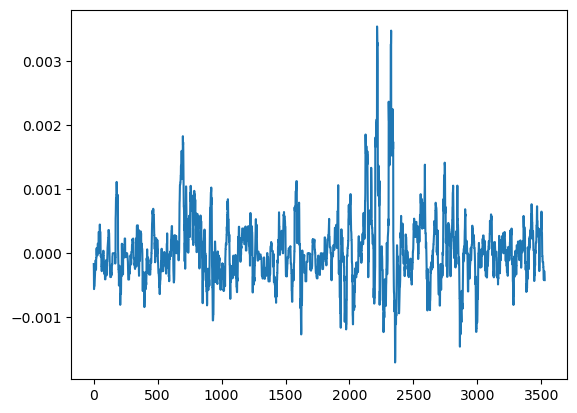

In [10]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)


final_dataset["log_return_20"].plot()
# final_dataset["log_return_1"].plot()

final_dataset[["mid_price", "log_return_20"]].head(25)

# Batch friendly Version for bigger datasets

In [11]:
from microstructure_alpha.features.lob_features import build_lob_feature_pipeline
from microstructure_alpha.features.trade_features import build_trade_feature_pipeline
from microstructure_alpha.features.merge_features import merge_lob_and_trade
from microstructure_alpha.utils.logger import setup_logger
import time
import glob
from pathlib import Path
import gc
from tqdm import tqdm

In [12]:
logger = setup_logger(
    "E:\\Quant_Projects\\microstructure-alpha-engine\\microstructure-alpha-engine\\logs\\feature_engineering_notebook.log"
)

In [13]:
def run_batch_feature_engineering_pipeline(
    lob_path: str, trade_path: str, save_path: str
):
    files_trade = sorted(glob.glob(trade_path + "trade_interim_*"))
    files_lob = sorted(glob.glob(lob_path + "lob_interim_*"))

    logger.info("Starting batch feature pipeline")
    logger.info(f"Found {len(files_trade)} trade files")
    logger.info(f"Found {len(files_lob)} lob files")

    total_batches = min(len(files_trade), len(files_lob))
    logger.info(f"Processing {total_batches} batches")

    for i, (trade_file, lob_file) in tqdm(
        enumerate(zip(files_trade, files_lob)),
        total=total_batches,
        desc="Processing batches",
    ):

        lob_df = pd.read_parquet(lob_file)
        trade_df = pd.read_parquet(trade_file)

        lob_with_features = build_lob_feature_pipeline(lob_df)
        trade_with_features = build_trade_feature_pipeline(trade_df)

        final_dataset = merge_lob_and_trade(trade_with_features, lob_with_features)

        final_dataset.to_parquet(save_path + f"final_dataset_{i}", compression="snappy")
    logger.info("Batch feature pipeline completed successfully")
    return

In [14]:
trade_path = "E:\\Quant_Projects\\microstructure-alpha-engine\\microstructure-alpha-engine\\data\\interim\\"

lob_path = "E:\\Quant_Projects\\microstructure-alpha-engine\\microstructure-alpha-engine\\data\\interim\\"

save_path = "E:\\Quant_Projects\\microstructure-alpha-engine\\microstructure-alpha-engine\\data\\processed\\"

RUN_PIPELINE = False
if RUN_PIPELINE:
    run_batch_feature_engineering_pipeline(lob_path, trade_path, save_path)